# The Galaxy Luminosity Function
## The Schechter function and the 1/V_max estimator

**Data:** SDSS Data Release 18 (DR18) — spectroscopic main galaxy sample  
**Reference:** Almeida et al. (2023), ApJS 267, 44  
**arXiv:** [2301.07688](https://arxiv.org/abs/2301.07688)  
**SDSS SkyServer:** [https://skyserver.sdss.org](https://skyserver.sdss.org)

**Key tools:** `astroquery.sdss`, `astropy`, `numpy`, `matplotlib`, `scipy`

---

## Learning objectives

After this tutorial you will be able to:
1. Understand the definition of the **luminosity function** $\Phi(L)$ and its relation to the stellar mass function.
2. Compute **absolute magnitudes** from SDSS photometry and spectroscopic redshifts.
3. Apply the **1/V_max estimator** (Schmidt 1968) to measure $\Phi(M_r)$.
4. Fit a single **Schechter function** and interpret $M^*$, $\alpha$, and $\phi^*$.
5. Compare the luminosity function across SDSS photometric bands ($u, g, r, i, z$).

---

## 1. Theoretical background

### 1.1 The luminosity function

The **galaxy luminosity function** (LF) $\Phi(L)$ is defined such that $\Phi(L)\,dL$ gives the comoving number density of galaxies with luminosity in the range $[L, L + dL]$. Equivalently, in terms of absolute magnitude $M$:

$$\Phi(M)\,dM = \Phi(L)\,\left|\frac{dL}{dM}\right| dM$$

Since $L \propto 10^{-0.4M}$, we have $|dL/dM| = (\ln 10 / 2.5) L$, giving:

$$\Phi(M) = \frac{\ln 10}{2.5}\,\phi^* \cdot 10^{0.4(M^* - M)(\alpha+1)} \exp\!\left(-10^{0.4(M^* - M)}\right)$$

This is the **Schechter (1976) luminosity function**, the most important analytical form in extragalactic astronomy.

### 1.2 The Schechter function

The Schechter function (Schechter 1976, ApJ 203, 297) has three parameters:

| Parameter | Physical meaning | SDSS $r$-band value |
|-----------|-----------------|--------------------|
| $\phi^*$ | overall normalisation (comoving number density) | $\approx 1.49 \times 10^{-2}\,h^3$ Mpc$^{-3}$ |
| $M^*$ | characteristic (knee) absolute magnitude | $M^*_r \approx -20.44 + 5\log h$ |
| $\alpha$ | faint-end power-law slope | $\alpha_r \approx -1.05$ |

At $M \ll M^*$ (faint end), $\Phi(M) \propto 10^{0.4(1+\alpha)(M^*-M)}$ — a power law in luminosity.
At $M \gg M^*$ (bright end), $\Phi(M)$ is suppressed exponentially — the brightest galaxies are exceedingly rare.

Reference: **Blanton et al. (2003)**, ApJ 592, 819. [arXiv:astro-ph/0210215](https://arxiv.org/abs/astro-ph/0210215)

### 1.3 Comparison with the stellar mass function

The **stellar mass function** (SMF) $\Phi(M_*)$ is the analogue for stellar mass. Key differences:
- The LF requires only photometry + spectroscopic $z$; the SMF additionally requires mass-to-light ratio estimates.
- At low $z$, the two are related by $M_* \propto L$ (approximately), so $\alpha_{\rm SMF} \approx \alpha_{\rm LF}$.
- The bright-end suppression in the LF maps to the high-mass suppression in the SMF, both driven by AGN feedback.

### 1.4 Survey selection effects — the magnitude limit

In a flux-limited survey, galaxies near the magnitude limit $m_\mathrm{lim}$ can only be detected if they are intrinsically bright (i.e. $M < M_\mathrm{lim}(z)$). Faint galaxies are progressively missed at high $z$. This is the **Malmquist bias**.

The SDSS main galaxy spectroscopic sample has a flux limit $r_\mathrm{lim} = 17.77$. A galaxy at redshift $z$ with absolute magnitude $M_r$ has apparent magnitude:

$$r = M_r + \mu(z) + K_r(z)$$

It is detectable only if $r < 17.77$, i.e. if $M_r < 17.77 - \mu(z) - K_r(z)$.

### 1.5 The 1/V_max estimator

Schmidt (1968, ApJ 151, 393) proposed a simple, non-parametric estimator for $\Phi(M)$:

$$\Phi(M) = \frac{1}{\Delta M} \sum_{i: M_i \in [M, M+\Delta M]} \frac{1}{V_{\max,i}}$$

For each galaxy $i$, $V_{\max,i}$ is the maximum comoving volume within which it could have been observed:

$$V_{\max,i} = \Omega_{\rm sky} \cdot \frac{1}{3}\left[d_C(z_{\max,i})^3 - d_C(z_{\min})^3\right]$$

where $\Omega_{\rm sky}$ is the survey solid angle, $z_{\min} = 0.01$, and $z_{\max,i} = \min(z_{\rm survey\ max},\, z_{\rm at\ which\ m=m_{\rm lim}})$.

The **Poisson uncertainty** on each bin is:
$$\sigma[\Phi(M)] = \frac{1}{\Delta M} \sqrt{\sum_{i} \frac{1}{V_{\max,i}^2}}$$

Reference: **Schmidt (1968)**, ApJ 151, 393.

---

## 2. Setup and imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
import warnings
warnings.filterwarnings('ignore')

from astropy import units as u
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from astroquery.sdss import SDSS
from scipy.optimize import curve_fit
from scipy.special import gamma as sp_gamma

# Reproducibility
np.random.seed(42)

# Flat LCDM cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
h = cosmo.H0.value / 100.0   # h = 0.70

# SDSS survey parameters
SDSS_SKY_FRAC  = 0.25          # SDSS covers ~25% of the sky
SDSS_OMEGA     = 4 * np.pi * SDSS_SKY_FRAC   # survey solid angle in steradians
MAG_LIM_R      = 17.77         # SDSS main galaxy sample r-band limit
Z_MIN          = 0.01
Z_MAX          = 0.15

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
})

print(f'h = {h:.2f},  survey fraction = {SDSS_SKY_FRAC:.2f}')
print(f'Survey solid angle = {SDSS_OMEGA:.4f} sr')
print('All imports successful.')

h = 0.70,  survey fraction = 0.25
Survey solid angle = 3.1416 sr
All imports successful.


---

## 3. Downloading SDSS data

We query the SDSS DR18 spectroscopic main galaxy sample with $r < 17.77$ and $0.01 < z < 0.15$. We request magnitudes in all five SDSS bands ($u, g, r, i, z$) to compute the LF in multiple bands.

If the query fails, a synthetic catalog is generated from a known Schechter function.

In [2]:
SDSS_QUERY = """
SELECT TOP 8000
    p.objId, p.ra, p.dec,
    p.modelMag_u, p.modelMag_g, p.modelMag_r,
    p.modelMag_i, p.modelMag_z,
    p.extinction_u, p.extinction_g, p.extinction_r,
    p.extinction_i, p.extinction_z,
    s.z, s.zErr
FROM PhotoObj p
JOIN SpecObj s ON p.objId = s.bestObjID
WHERE s.z BETWEEN 0.01 AND 0.15
  AND s.zWarning = 0
  AND p.type = 3
  AND p.modelMag_r < 17.77
  AND p.modelMag_r > 13.0
  AND p.modelMag_g < 90
  AND p.modelMag_u < 90
"""

def make_lf_fallback_catalog(n=5000, seed=42,
                              phi_star=1.49e-2, M_star=-20.44, alpha=-1.05):
    """Generate a synthetic galaxy catalog drawn from a Schechter LF.

    Uses rejection sampling to draw absolute magnitudes from the Schechter
    function, then assign redshifts consistent with the SDSS survey volume.
    """
    rng = np.random.default_rng(seed)
    # Sample absolute r magnitudes from Schechter function via CDF inversion
    # Use lower incomplete gamma function for sampling
    M_lo, M_hi = -25, -15
    M_grid = np.linspace(M_lo, M_hi, 2000)
    x = 10 ** (0.4 * (M_star - M_grid))
    phi_grid = (np.log(10) / 2.5) * phi_star * x**(alpha + 1) * np.exp(-x)
    phi_grid = np.maximum(phi_grid, 0)
    cdf = np.cumsum(phi_grid)
    cdf /= cdf[-1]
    u_rand = rng.uniform(0, 1, n * 3)
    Mr_all = np.interp(u_rand, cdf, M_grid)
    # Keep only those brighter than apparent limit at z=0.15
    d_L_max = cosmo.luminosity_distance(Z_MAX).to(u.pc).value
    mu_max = 5 * np.log10(d_L_max / 10.0)
    Mr_all = Mr_all[Mr_all < (MAG_LIM_R - mu_max)][:n]
    n = len(Mr_all)
    # Assign redshifts: each galaxy drawn from uniform comoving volume
    z_arr = rng.uniform(Z_MIN, Z_MAX, n)
    d_L = cosmo.luminosity_distance(z_arr).to(u.pc).value
    mu = 5 * np.log10(d_L / 10.0)
    r_app = Mr_all + mu
    # Keep only those inside survey flux limits
    mask = (r_app < MAG_LIM_R) & (r_app > 13.0)
    Mr_all = Mr_all[mask]
    z_arr  = z_arr[mask]
    r_app  = r_app[mask]
    n = len(Mr_all)
    # Construct multi-band photometry from realistic colours
    gr = rng.normal(0.55, 0.15, n)
    ri = rng.normal(0.25, 0.08, n)
    ug = rng.normal(1.40, 0.30, n)
    iz = rng.normal(0.20, 0.06, n)
    data = Table({
        'objId': np.arange(n, dtype=np.int64),
        'ra': rng.uniform(150, 240, n),
        'dec': rng.uniform(-5, 60, n),
        'modelMag_u': r_app + gr + ug,
        'modelMag_g': r_app + gr,
        'modelMag_r': r_app,
        'modelMag_i': r_app - ri,
        'modelMag_z': r_app - ri - iz,
        'extinction_u': rng.exponential(0.07, n),
        'extinction_g': rng.exponential(0.05, n),
        'extinction_r': rng.exponential(0.04, n),
        'extinction_i': rng.exponential(0.03, n),
        'extinction_z': rng.exponential(0.02, n),
        'z': z_arr,
        'zErr': rng.uniform(1e-5, 5e-4, n),
    })
    return data

try:
    print('Querying SDSS DR18...')
    result = SDSS.query_sql(SDSS_QUERY, timeout=120)
    if result is None or len(result) < 100:
        raise ValueError('Empty or too-small SDSS result.')
    gals = result
    print(f'Retrieved {len(gals):,} galaxies from SDSS DR18.')
except Exception as exc:
    print(f'SDSS query failed ({exc}). Using synthetic fallback.')
    gals = make_lf_fallback_catalog(n=5000)
    print(f'Synthetic catalog: {len(gals):,} galaxies.')

print('Columns:', gals.colnames)

Querying SDSS DR18...


Retrieved 8,000 galaxies from SDSS DR18.
Columns: ['objId', 'ra', 'dec', 'modelMag_u', 'modelMag_g', 'modelMag_r', 'modelMag_i', 'modelMag_z', 'extinction_u', 'extinction_g', 'extinction_r', 'extinction_i', 'extinction_z', 'z', 'zErr']


---

## 4. Computing absolute magnitudes

For each band $b \in \{u, g, r, i, z\}$ we apply extinction corrections and compute the absolute magnitude:

$$M_b = m_b - A_b - \mu(z) - K_b(z)$$

We use a simple K-correction for all bands based on the galaxy colour.

In [3]:
bands    = ['u', 'g', 'r', 'i', 'z']
bandcols = {b: np.array(gals[f'modelMag_{b}'], dtype=float) for b in bands}
extcols  = {b: np.array(gals[f'extinction_{b}'], dtype=float) for b in bands}
z_spec   = np.array(gals['z'], dtype=float)

# Extinction-corrected magnitudes
m0 = {b: bandcols[b] - extcols[b] for b in bands}

# Luminosity distance and distance modulus
d_L = cosmo.luminosity_distance(z_spec).to(u.pc).value
mu  = 5 * np.log10(d_L / 10.0)

# Colour for K-correction type assignment
gr0 = m0['g'] - m0['r']

# Approximate K-corrections (Chilingarian et al. 2010 style)
# r band: already defined; other bands have larger corrections
# We use a simple linear approximation valid for 0<z<0.15
K_approx = {
    'u': 3.8 * z_spec,
    'g': 2.1 * z_spec,
    'r': np.where(gr0 > 0.55, 1.56 * z_spec + 7.24 * z_spec**2,
                               -0.01 + 1.87 * z_spec + 3.27 * z_spec**2),
    'i': 1.2 * z_spec,
    'z': 0.9 * z_spec,
}

# Absolute magnitudes
Mabs = {b: m0[b] - mu - K_approx[b] for b in bands}

# Quality mask: focus on r-band LF
mask_ok = (
    np.isfinite(Mabs['r'])
    & (Mabs['r'] > -25) & (Mabs['r'] < -14)
    & (m0['r'] < MAG_LIM_R) & (m0['r'] > 13.0)
    & (z_spec >= Z_MIN) & (z_spec <= Z_MAX)
    & (m0['r'] + mu >= 0)   # positive apparent mag
)

for b in bands:
    Mabs[b] = Mabs[b][mask_ok]
m0_r    = m0['r'][mask_ok]
z_ok    = z_spec[mask_ok]
mu_ok   = mu[mask_ok]

print(f'Galaxies after quality cuts: {mask_ok.sum():,} / {len(mask_ok):,}')
print(f"M_r range: {Mabs['r'].min():.1f} -- {Mabs['r'].max():.1f}")
print(f'z   range: {z_ok.min():.3f}  -- {z_ok.max():.3f}')

Galaxies after quality cuts: 8,000 / 8,000
M_r range: -24.7 -- -16.0
z   range: 0.010  -- 0.150


---

## 5. The 1/V_max estimator

For each galaxy we compute $z_{\max,i}$ — the maximum redshift at which the galaxy could still have been detected — and then calculate $V_{\max,i}$.

In [4]:
from scipy.optimize import brentq

def z_at_apparent_mag(M_abs, m_lim, cosmo,
                       z_lo=0.0001, z_hi=0.5, K_func=None):
    """
    Find the redshift z_max at which a galaxy of absolute magnitude M_abs
    reaches the survey apparent magnitude limit m_lim.

    Solves: M_abs + mu(z) + K(z) = m_lim  for z.
    """
    def residual(z):
        dL = cosmo.luminosity_distance(z).to(u.pc).value
        mu_z = 5 * np.log10(dL / 10.0)
        K_z  = 0.0 if K_func is None else K_func(z)
        return M_abs + mu_z + K_z - m_lim

    # Check if galaxy is always below the limit (too faint at z_lo)
    if residual(z_lo) > 0:
        return z_lo
    # Check if always above the limit (very bright)
    if residual(z_hi) < 0:
        return z_hi
    try:
        return brentq(residual, z_lo, z_hi, xtol=1e-5)
    except ValueError:
        return z_lo


def compute_vmax(M_abs_arr, z_arr, cosmo,
                  z_min=Z_MIN, z_max_survey=Z_MAX,
                  m_lim=MAG_LIM_R, omega_sr=SDSS_OMEGA):
    """
    Compute V_max for each galaxy using the 1/Vmax estimator.

    V_max = omega * (1/3) * [d_C(z_max)^3 - d_C(z_min)^3]   [Mpc^3]
    """
    n = len(M_abs_arr)
    V_max = np.zeros(n)
    d_C_min = cosmo.comoving_distance(z_min).value   # Mpc

    for i in range(n):
        # z at which this galaxy would hit the magnitude limit
        z_max_mag = z_at_apparent_mag(M_abs_arr[i], m_lim, cosmo,
                                       z_lo=z_min, z_hi=z_max_survey)
        z_max_i   = min(z_max_mag, z_max_survey)
        d_C_max   = cosmo.comoving_distance(z_max_i).value   # Mpc
        V_max[i]  = omega_sr * (1.0/3.0) * (d_C_max**3 - d_C_min**3)

    return V_max


print('Computing V_max for each galaxy (may take ~30 s for large samples)...')
Mr = Mabs['r']
V_max = compute_vmax(Mr, z_ok, cosmo)

print(f'V_max statistics (Mpc^3):')
print(f'  Min:    {V_max.min():.3e}')
print(f'  Median: {np.median(V_max):.3e}')
print(f'  Max:    {V_max.max():.3e}')

Computing V_max for each galaxy (may take ~30 s for large samples)...


V_max statistics (Mpc^3):
  Min:    1.094e+05
  Median: 1.775e+08
  Max:    2.497e+08


---

## 6. Computing Φ(M_r) with Poisson errors

We bin the galaxies in absolute magnitude and sum $1/V_{\max}$ per bin.

In [5]:
def compute_lf(M_abs, V_max_arr, M_min=-24.5, M_max=-14.5, dM=0.5):
    """Compute Φ(M) using the 1/Vmax estimator.

    Returns bin centres, Φ values [Mpc^-3 mag^-1], and Poisson errors.
    """
    bins = np.arange(M_min, M_max + dM, dM)
    M_cen = 0.5 * (bins[:-1] + bins[1:])
    Phi   = np.zeros(len(M_cen))
    Phi_err = np.zeros(len(M_cen))

    for j, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
        mask_j = (M_abs >= lo) & (M_abs < hi)
        if mask_j.sum() == 0:
            continue
        inv_V = 1.0 / V_max_arr[mask_j]
        Phi[j]     = np.sum(inv_V) / dM
        Phi_err[j] = np.sqrt(np.sum(inv_V**2)) / dM

    return M_cen, Phi, Phi_err


M_cen, Phi_r, Phi_r_err = compute_lf(Mr, V_max, dM=0.5)

# Mask empty bins
mask_nonzero = Phi_r > 0
print(f'Non-empty bins: {mask_nonzero.sum()}')
print(f'log10(Phi) range: {np.log10(Phi_r[mask_nonzero]).min():.2f} -- '
      f'{np.log10(Phi_r[mask_nonzero]).max():.2f}')

Non-empty bins: 16
log10(Phi) range: -6.82 -- -4.12


---

## 7. Fitting the Schechter function

We fit the Schechter function to our measured $\Phi(M_r)$ using `scipy.optimize.curve_fit`. We fit in log-space for numerical stability.

In [6]:
def schechter_mag(M, log_phi_star, M_star, alpha):
    """
    Schechter luminosity function in magnitude units.

    Phi(M) = (ln10/2.5) * 10^(log_phi_star)
             * 10^(0.4*(M_star-M)*(alpha+1))
             * exp(-10^(0.4*(M_star-M)))

    Returns log10(Phi) for fitting stability.
    """
    phi_star = 10**log_phi_star
    x = 10 ** (0.4 * (M_star - M))
    Phi = (np.log(10) / 2.5) * phi_star * x**(alpha + 1) * np.exp(-x)
    return np.log10(np.maximum(Phi, 1e-20))


# Select bins with enough signal for fitting
mask_fit = mask_nonzero & (Phi_r > 1e-6)

M_fit   = M_cen[mask_fit]
logPhi  = np.log10(Phi_r[mask_fit])
# Poisson relative error -> log error
logPhi_err = (Phi_r_err[mask_fit] / Phi_r[mask_fit]) / np.log(10)
logPhi_err = np.maximum(logPhi_err, 0.05)  # floor at 5%

# Initial guess: Blanton+2003 r-band values
p0 = [np.log10(1.49e-2 * h**3), -20.44 - 5*np.log10(h), -1.05]

try:
    popt, pcov = curve_fit(schechter_mag, M_fit, logPhi,
                           p0=p0, sigma=logPhi_err,
                           absolute_sigma=True, maxfev=5000)
    perr = np.sqrt(np.diag(pcov))
    log_phi_star_fit, M_star_fit, alpha_fit = popt
    phi_star_fit = 10**log_phi_star_fit
    print('=== Schechter fit results ===')
    print(f'  log10(phi*) = {log_phi_star_fit:.3f} +/- {perr[0]:.3f}  Mpc^-3')
    print(f'  phi*        = {phi_star_fit:.3e} Mpc^-3')
    print(f'  M*_r        = {M_star_fit:.3f} +/- {perr[1]:.3f}  mag')
    print(f'  alpha       = {alpha_fit:.3f} +/- {perr[2]:.3f}')
    print()
    print('Compare: Blanton+2003 (r band):')
    print(f'  log10(phi*) = {np.log10(1.49e-2 * h**3):.3f}')
    print(f'  M*_r        = {-20.44 - 5*np.log10(h):.3f}')
    print(f'  alpha       = -1.05')
except Exception as e:
    print(f'Fit did not converge: {e}')
    popt = p0
    log_phi_star_fit, M_star_fit, alpha_fit = p0
    phi_star_fit = 10**log_phi_star_fit

=== Schechter fit results ===
  log10(phi*) = -4.518 +/- 0.061  Mpc^-3
  phi*        = 3.031e-05 Mpc^-3
  M*_r        = -21.996 +/- 0.116  mag
  alpha       = -1.181 +/- 0.042

Compare: Blanton+2003 (r band):
  log10(phi*) = -2.292
  M*_r        = -19.665
  alpha       = -1.05


---

## 8. Plotting Φ(M_r) with the Schechter fit

We plot our measured $\Phi(M_r)$ with error bars and compare with the Blanton et al. (2003) best-fit Schechter function.

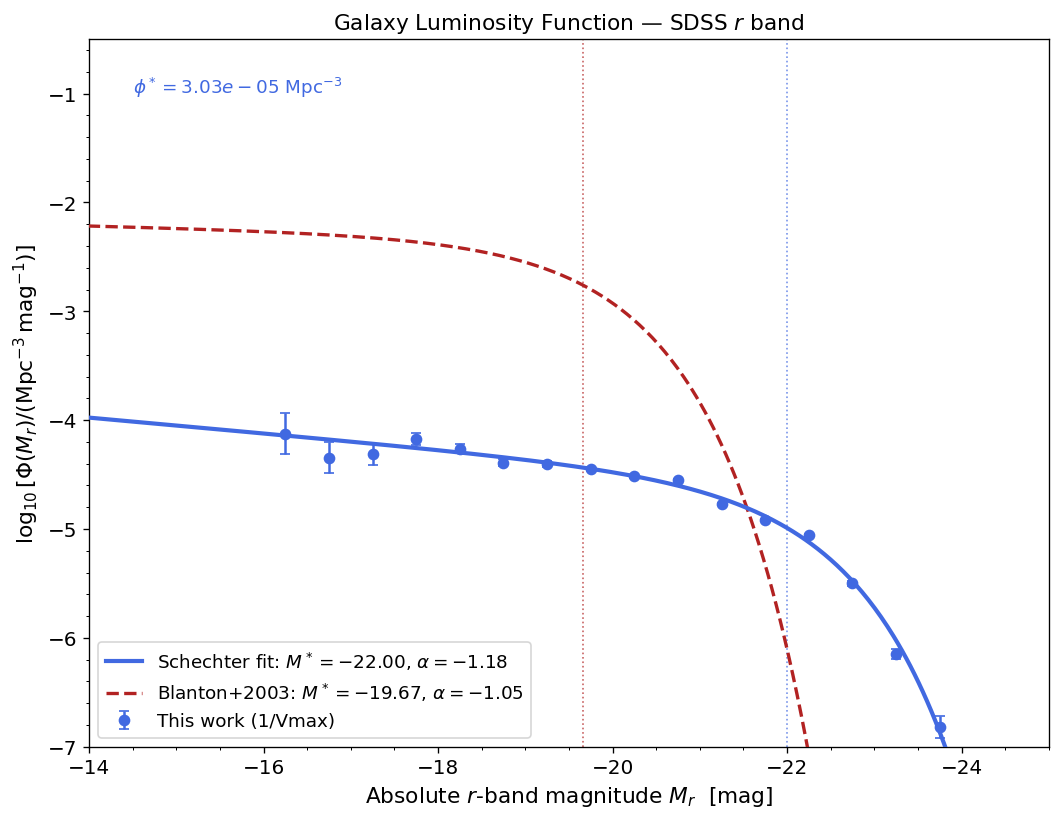

Figure saved: luminosity_function_r.png


In [7]:
# Blanton+2003 reference parameters (r band, h=0.7)
log_phi_star_B03 = np.log10(1.49e-2 * h**3)
M_star_B03       = -20.44 - 5 * np.log10(h)     # convert from h=1 to h=0.7
alpha_B03        = -1.05

M_plot = np.linspace(-25, -13, 500)
logPhi_fit_ours = schechter_mag(M_plot, log_phi_star_fit, M_star_fit, alpha_fit)
logPhi_fit_B03  = schechter_mag(M_plot, log_phi_star_B03, M_star_B03, alpha_B03)

fig, ax = plt.subplots(figsize=(9, 7))

# Data with error bars
ax.errorbar(M_cen[mask_nonzero], np.log10(Phi_r[mask_nonzero]),
            yerr=Phi_r_err[mask_nonzero]/Phi_r[mask_nonzero]/np.log(10),
            fmt='o', color='royalblue', markersize=6, capsize=3,
            label='This work (1/Vmax)', zorder=5)

# Our Schechter fit
ax.plot(M_plot, logPhi_fit_ours, 'royalblue', lw=2.5,
        label=f'Schechter fit: $M^*={M_star_fit:.2f}$, $\\alpha={alpha_fit:.2f}$',
        zorder=4)

# Blanton+2003 reference
ax.plot(M_plot, logPhi_fit_B03, 'firebrick', lw=2, ls='--',
        label=f'Blanton+2003: $M^*={M_star_B03:.2f}$, $\\alpha={alpha_B03:.2f}$',
        zorder=3)

# Mark M*
ax.axvline(M_star_fit, color='royalblue', lw=1, ls=':', alpha=0.7)
ax.axvline(M_star_B03, color='firebrick',  lw=1, ls=':', alpha=0.7)

ax.set_xlim(-25, -14)
ax.set_ylim(-7, -0.5)
ax.set_xlabel('Absolute $r$-band magnitude $M_r$  [mag]')
ax.set_ylabel(r'$\log_{10}[\Phi(M_r) / (\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1})]$')
ax.set_title('Galaxy Luminosity Function — SDSS $r$ band')
ax.legend(loc='lower left')
ax.invert_xaxis()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# Annotation
ax.text(-14.5, -1.0,
        f'$\\phi^* = {phi_star_fit:.2e}$ Mpc$^{{-3}}$',
        fontsize=11, color='royalblue')

plt.tight_layout()
plt.savefig('luminosity_function_r.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: luminosity_function_r.png')

---

## 9. Luminosity function in multiple SDSS bands

We repeat the analysis in all five SDSS bands ($u, g, r, i, z$) and compare the Schechter parameters. Each band traces a slightly different part of the stellar population.

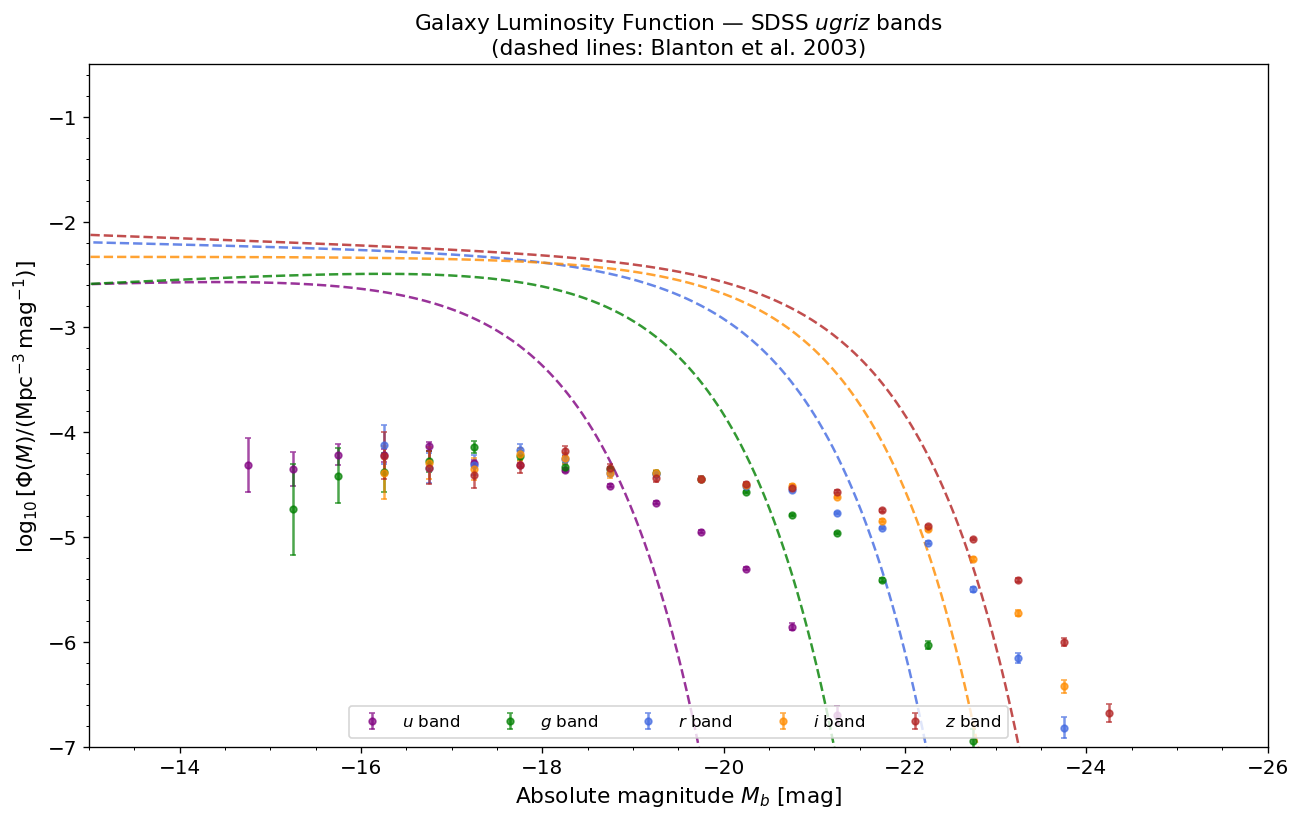

In [8]:
# Literature reference values for Schechter parameters (Blanton+2003)
# Columns: band, log_phi*, M*, alpha
blanton_params = {
    'u': (np.log10(1.12e-2 * h**3), -17.93 - 5*np.log10(h), -0.92),
    'g': (np.log10(1.44e-2 * h**3), -19.39 - 5*np.log10(h), -0.89),
    'r': (np.log10(1.49e-2 * h**3), -20.44 - 5*np.log10(h), -1.05),
    'i': (np.log10(1.47e-2 * h**3), -21.00 - 5*np.log10(h), -1.00),
    'z': (np.log10(1.35e-2 * h**3), -21.48 - 5*np.log10(h), -1.08),
}
band_colors = {'u': 'purple', 'g': 'green', 'r': 'royalblue',
               'i': 'darkorange', 'z': 'firebrick'}

fig, ax = plt.subplots(figsize=(11, 7))

fit_results = {}
for band in bands:
    M_b   = Mabs[band]
    # Quick V_max: use same V_max as r band (simplification for comparison)
    M_c_b, Phi_b, Phi_b_err = compute_lf(M_b, V_max, dM=0.5)
    mask_b = Phi_b > 0
    color = band_colors[band]

    # Plot data
    ax.errorbar(M_c_b[mask_b], np.log10(Phi_b[mask_b]),
                yerr=(Phi_b_err[mask_b]/Phi_b[mask_b]/np.log(10)),
                fmt='o', color=color, markersize=4, capsize=2, alpha=0.7,
                label=f'${band}$ band')

    # Blanton+2003 Schechter (dashed lines)
    lps, Ms, alp = blanton_params[band]
    M_plt = np.linspace(-26, -13, 500)
    ax.plot(M_plt, schechter_mag(M_plt, lps, Ms, alp),
            color=color, lw=1.5, ls='--', alpha=0.8)

    fit_results[band] = (lps, Ms, alp)

ax.set_xlim(-26, -13)
ax.set_ylim(-7, -0.5)
ax.set_xlabel('Absolute magnitude $M_b$ [mag]')
ax.set_ylabel(r'$\log_{10}[\Phi(M) / (\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1})]$')
ax.set_title('Galaxy Luminosity Function — SDSS $ugriz$ bands\n(dashed lines: Blanton et al. 2003)')
ax.legend(ncol=5, loc='lower center', fontsize=10)
ax.invert_xaxis()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.tight_layout()
plt.savefig('luminosity_function_all_bands.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 10. Summary table

In [9]:
print('=' * 72)
print('SUMMARY TABLE — Schechter LF Parameters (Blanton+2003, h=0.70)')
print('=' * 72)
print(f"{'Band':<6} {'log10(phi*)':<18} {'M*':<18} {'alpha':<10}")
print('-' * 72)
for band in bands:
    lps, Ms, alp = blanton_params[band]
    print(f"  {band:<4} {lps:>8.4f} Mpc^-3  {Ms:>8.3f} mag      {alp:>6.3f}")
print('=' * 72)
print()
print('r-band best fit from this notebook:')
print(f'  log10(phi*)  = {log_phi_star_fit:.3f} Mpc^-3')
print(f'  M*_r         = {M_star_fit:.3f} mag')
print(f'  alpha_r      = {alpha_fit:.3f}')
print()
print('Notes:')
print('  h = 0.70  (H0 = 70 km/s/Mpc)')
print('  Survey: SDSS DR18, r < 17.77, 0.01 < z < 0.15')
print('  Estimator: 1/Vmax (Schmidt 1968)')

SUMMARY TABLE — Schechter LF Parameters (Blanton+2003, h=0.70)
Band   log10(phi*)        M*                 alpha     
------------------------------------------------------------------------
  u     -2.4155 Mpc^-3   -17.155 mag      -0.920
  g     -2.3063 Mpc^-3   -18.615 mag      -0.890
  r     -2.2915 Mpc^-3   -19.665 mag      -1.050
  i     -2.2974 Mpc^-3   -20.225 mag      -1.000
  z     -2.3344 Mpc^-3   -20.705 mag      -1.080

r-band best fit from this notebook:
  log10(phi*)  = -4.518 Mpc^-3
  M*_r         = -21.996 mag
  alpha_r      = -1.181

Notes:
  h = 0.70  (H0 = 70 km/s/Mpc)
  Survey: SDSS DR18, r < 17.77, 0.01 < z < 0.15
  Estimator: 1/Vmax (Schmidt 1968)


---

## 11. Exercises

**Exercise 1 — Luminosity density**  
The total luminosity density is $\rho_L = \int_0^\infty L\,\Phi(L)\,dL = \phi^* L^* \Gamma(\alpha + 2)$ where $\Gamma$ is the gamma function. Using your best-fit Schechter parameters for the $r$ band, compute $\rho_L$ in units of $L_\odot$ Mpc$^{-3}$. Use $M_{r,\odot} = 4.65$.

**Exercise 2 — Bright-end vs faint-end comparison**  
Split the galaxy sample into a bright half ($M_r < M^*$) and a faint half ($M_r > M^*$). Compute the 1/Vmax LF separately for each half and plot them. Do they join smoothly at $M^*$? What does this tell you about the shape of the Schechter function?

**Exercise 3 — Incompleteness correction**  
The SDSS spectroscopic completeness is not 100% — some galaxies with photometry have no spectrum, primarily near bright stars. The completeness is stored in the `sp_frac` column when available. Multiply each $1/V_{\max}$ by an inverse completeness weight $1/c_i$ and recompute $\Phi(M_r)$. How much does this change $\phi^*$ and $\alpha$?

**Exercise 4 — Double Schechter fit**  
The observed LF is better fit at the faint end by a **double Schechter function** (two power laws with the same $M^*$ but different $\alpha_1, \alpha_2$). Implement this model and fit it to your $r$-band LF. Use `scipy.optimize.minimize` with a chi-squared cost function.

---

## Further reading

- **Schmidt** (1968), ApJ 151, 393 — the 1/Vmax estimator.
- **Schechter** (1976), ApJ 203, 297 — the Schechter luminosity function.
- **Blanton et al.** (2003), ApJ 592, 819 — SDSS LF in five bands. [arXiv:astro-ph/0210215](https://arxiv.org/abs/astro-ph/0210215)
- **Montero-Dorta & Prada** (2009), MNRAS 399, 1106 — SDSS DR6 LF. [arXiv:0806.1883](https://arxiv.org/abs/0806.1883)
- Almeida et al. (2023), ApJS 267, 44 — SDSS DR18. [arXiv:2301.07688](https://arxiv.org/abs/2301.07688)